# 01 - Audit des rendements
Objectif : savoir si les donnees suffisent pour modeliser (go / no-go).

In [1]:
import sys; sys.path.append("..")
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import load_config
from src.data.load_yields import load_yields
from src.data.audit import yield_matrix, missing_report, flag_outliers

cfg = load_config("maize")   # changer ici pour une autre culture

Matplotlib is building the font cache; this may take a moment.


## 1. Chargement
Verifier d'abord que `config/maize.yaml` correspond aux colonnes de votre fichier.

In [2]:
df = load_yields(cfg)
df.head()

,admin,year,value
0,Aguégués,2010,0.474662
1,Akpro-Missérété,2010,0.476592
2,Dangbo,2010,0.282881
3,Comè,2006,0.836182
4,Ifangni,2010,0.604000


## 2. Tableau departements x annees

In [3]:
m = yield_matrix(df)
print(missing_report(m))
m

{'zones': 77, 'annees': 24, 'cellules_possibles': 1848, 'cellules_renseignees': 1828, 'taux_remplissage': 0.989}


year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
admin,,,,,,,,,,,,,,,,,,,,,
Abomey,0.802985,0.782869,1.014371,0.753776,0.814013,0.760386,0.744914,0.876597,1.333997,1.413210,...,0.928695,0.943226,0.911575,0.946850,0.909420,0.735724,0.894183,0.907147,0.871460,0.700107
Abomey-Calavi,0.793193,0.849456,1.039139,0.896952,0.946254,1.126588,1.255480,1.391838,1.649898,1.442078,...,1.460534,0.997933,1.035942,1.016588,1.219679,0.986725,0.933046,0.922540,0.901699,0.907129
Adja-Ouèrè,1.312178,1.461695,1.192153,1.639166,1.233465,1.201083,0.314289,0.738666,1.041181,1.144736,...,1.142995,0.994491,1.079612,1.097682,1.075933,0.870434,0.882918,1.125109,1.213897,0.838603
Adjarra,0.947368,0.908155,0.905855,0.922360,0.904374,0.791592,0.752033,0.644922,0.807130,0.733865,...,1.184225,1.190224,1.232975,1.050886,1.142822,0.924548,0.924075,0.924075,0.834874,0.828731
Adjohoun,1.082362,0.817745,0.952427,0.554490,1.570384,1.320402,1.052293,0.912788,1.042549,1.008811,...,1.664679,1.666287,1.736247,1.593059,1.536512,1.243045,1.230246,1.500000,1.224780,1.119408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Toviklin,0.842823,0.966848,0.737720,0.883636,0.902897,0.869375,0.887865,0.887362,0.863557,0.941514,...,0.966106,0.912804,1.070632,1.059346,1.011047,0.817941,1.076623,0.751865,0.831907,0.766900
Za-Kpota,0.844477,0.782917,0.938515,0.790390,0.867590,0.759305,0.887996,0.849680,0.813086,0.863940,...,0.909579,0.931629,0.912467,0.917411,0.900531,0.728534,0.912706,0.919003,0.889258,0.700603
Zagnanado,0.770031,0.708298,0.683357,0.673827,0.824420,0.674945,0.657648,0.676487,0.961917,1.030000,...,0.978843,0.947950,0.953024,1.002998,0.961617,0.777952,0.857715,0.954812,0.921439,0.732382


## 3. Carte des valeurs manquantes

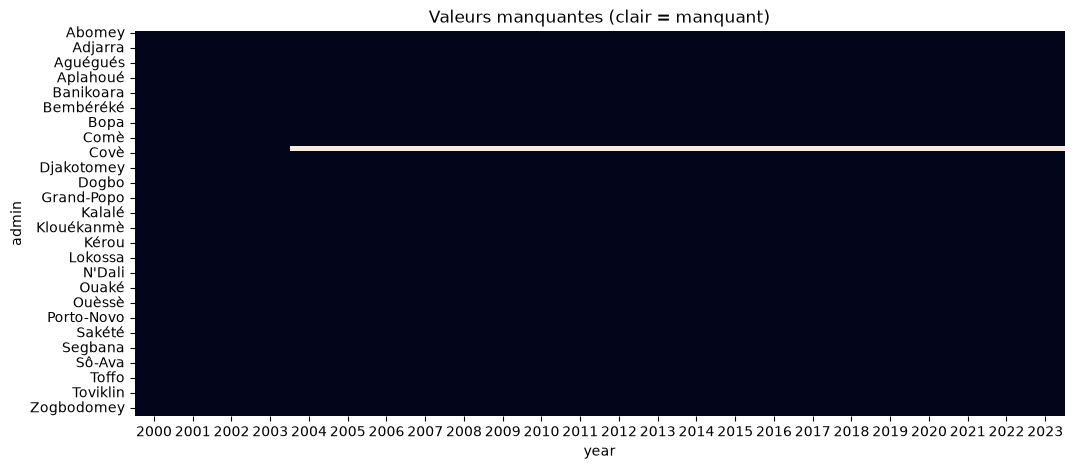

In [4]:
plt.figure(figsize=(12, 5))
sns.heatmap(m.isna(), cbar=False)
plt.title("Valeurs manquantes (clair = manquant)")
plt.show()

## 4. Valeurs suspectes
Distinguer *zero reel* de *non disponible*.

In [5]:
flag_outliers(df)

,admin,year,value
9,Abomey,2011,1.703105
67,Nikki,2013,1.961780
244,Porto-Novo,2013,2.232104
262,Sèmè-Kpodji,2010,2.482759
287,Agbangnizoun,2000,2.037849
302,Bohicon,2000,1.363281
314,Covè,2003,0.085371
366,Za-Kpota,2011,1.262345
470,Lokossa,2011,2.414602
690,Sô-Ava,2001,3.658627


## 5. Evolution des rendements

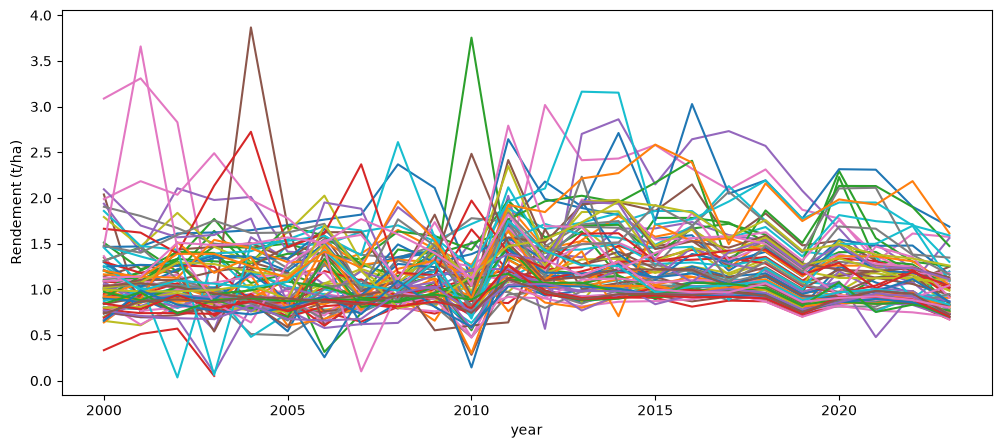

In [6]:
m.T.plot(figsize=(12, 5), legend=False)
plt.ylabel("Rendement (t/ha)")
plt.show()

## 6. Conclusion (a remplir)
- Nombre de lignes exploitables :
- Departements bien couverts :
- Decision : continuer / elargir (autres cultures, pays voisins) :

## Ville avec aucune donnée à partir de 2023

In [7]:
m[m.isna().any(axis=1)].index.tolist()

['Cotonou']